In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip '/content/drive/MyDrive/Teeth/Teeth_DataSet.zip' -d '/content/dataset' > /dev/null

replace /content/dataset/Teeth_Dataset/Testing/OC/oc_1239_0_6735.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
#Libraries used:

import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import os

In [ ]:
#Configuration

mixed_precision.set_global_policy('mixed_float16') #Using both 16-bit and 32-bit floating-points in a model to make training faster and use less memory

img_size = (224,224)
img_shape = (224,224,3)
batch = 64
epochs = 30
fine_tune_epochs = 15

train = '/content/dataset/Teeth_Dataset/Training'
test = '/content/dataset/Teeth_Dataset/Testing'
val = '/content/dataset/Teeth_Dataset/Validation'

In [ ]:
#Data Pipeline

train_ds = tf.keras.utils.image_dataset_from_directory(
    train,
    image_size = img_size,
    batch_size = batch
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test,
    image_size = img_size,
    batch_size = batch,
    shuffle = False
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val,
    image_size = img_size,
    batch_size = batch
)

class_names = train_ds.class_names
num_classes = len(class_names)

print('Classes: ', class_names)


data_augmenation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])

def preprocess (image, label, training = False):

  if training:
    image = data_augmenation(image)
  image = preprocess_input(image)
  return image, label

train_ds = train_ds.map(lambda x, y: preprocess(x, y, training=True))
val_ds = val_ds.map(lambda x, y: preprocess(x, y, training=False))
test_ds = test_ds.map(lambda x, y: preprocess(x, y, training=False))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3087 files belonging to 7 classes.
Found 1028 files belonging to 7 classes.
Found 1028 files belonging to 7 classes.
Classes:  ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


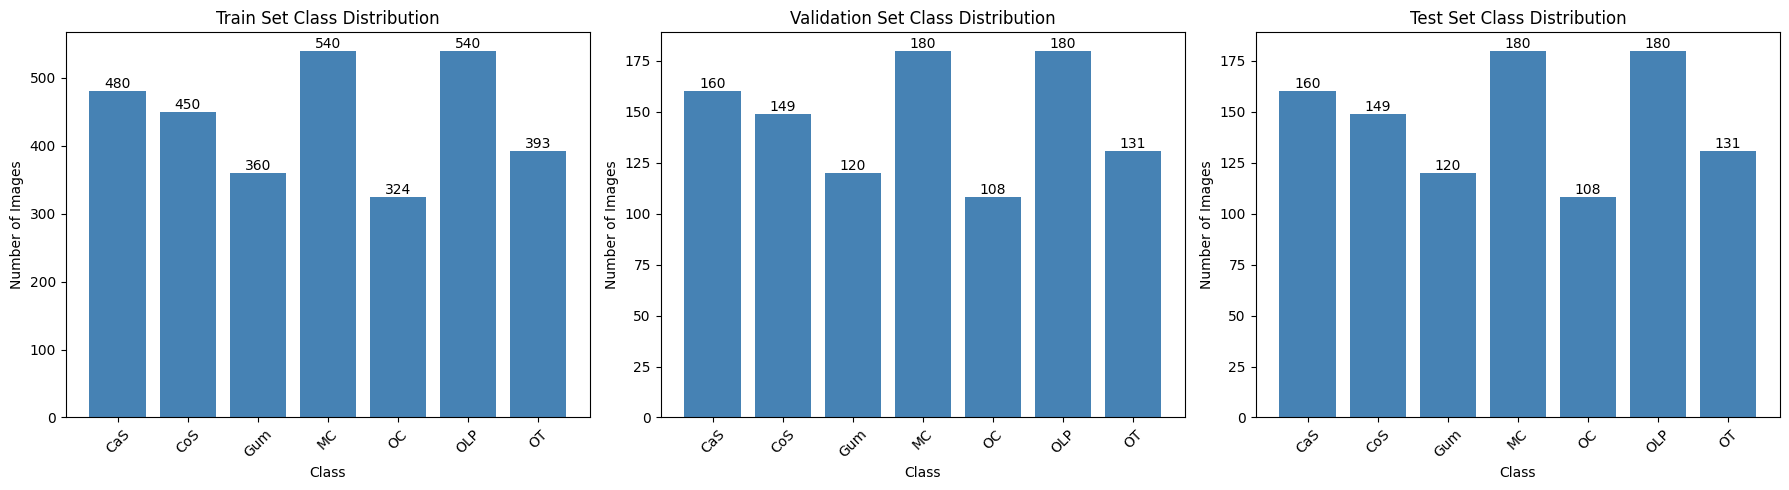

In [ ]:
#Visualization

def images_per_class(directory , class_names):
  counts = []
  for cls in class_names:
    cls_path = os.path.join(directory, cls)
    counts.append(len(os.listdir(cls_path)))
  return counts

train_counts = images_per_class(train, class_names)
val_counts = images_per_class(val, class_names)
test_counts = images_per_class(test, class_names)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, counts, title in zip(
    axes,
    [train_counts, val_counts, test_counts],
    ['Train', 'Validation', 'Test']
):
    bars = ax.bar(class_names, counts, color='steelblue')
    ax.set_title(f'{title} Set Class Distribution')
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=45)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Found 3087 files belonging to 7 classes.


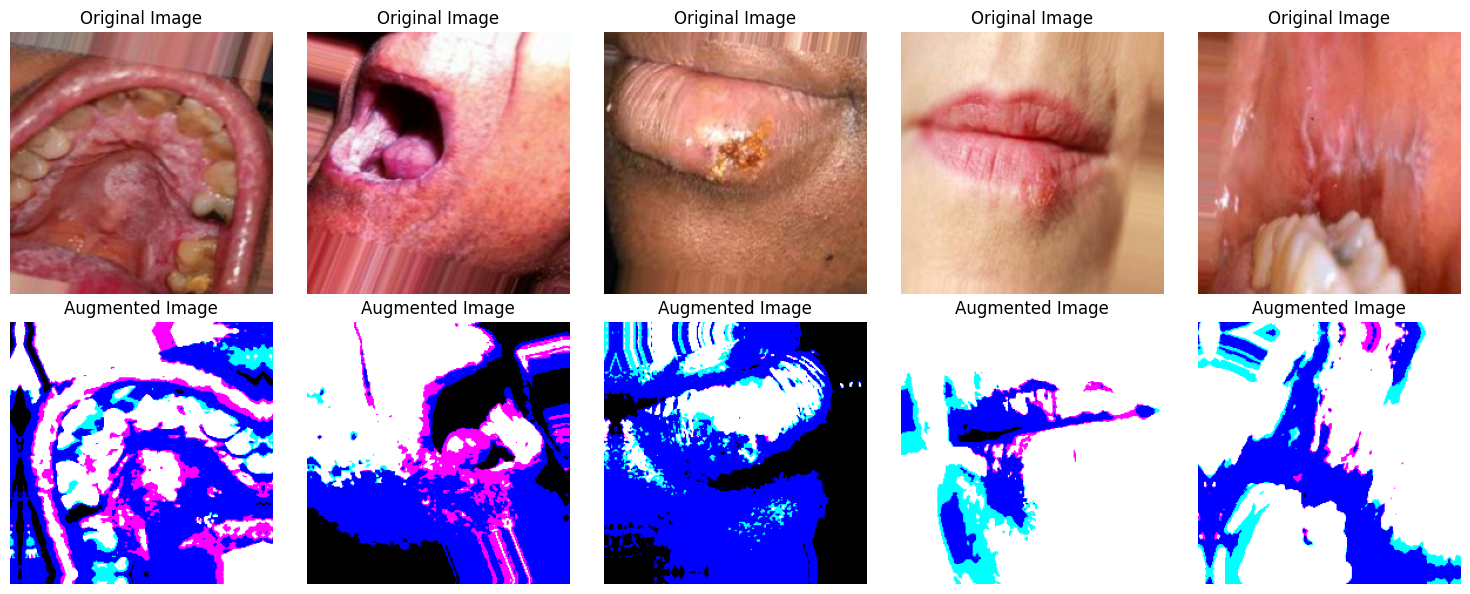

In [ ]:
#Visualization before and after data augmentation

raw_ds = tf.keras.utils.image_dataset_from_directory(
    train,
    image_size = img_size,
    batch_size = batch,
    shuffle = True
)

images, labels = next(iter(raw_ds.take(1)))
num_examples = 5

plt.figure(figsize=(15,6))

for i in range(num_examples):
  original_img = images[i]
  augmented_img = data_augmenation(tf.expand_dims(original_img,0))[0]
  augmented_img = preprocess_input(augmented_img)

  original_np = np.array(original_img, dtype=np.float32) / 255.0
  augmented_np = np.clip(np.array(augmented_img, dtype=np.float32), 0,1)


  plt.subplot(2, num_examples, i+1)
  plt.imshow(original_np)
  plt.title("Original Image")
  plt.axis('off')

  plt.subplot(2, num_examples, num_examples+i+1)
  plt.imshow(augmented_np)
  plt.title("Augmented Image")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Class Weights

class_counts = {}
for idx in range(len(class_names)):
    cls_path = os.path.join(train, class_names[idx])
    class_counts[idx] = len(os.listdir(cls_path))

total_images = sum(class_counts.values())

class_weights = {}
for label in class_counts:
    class_weights[label] = total_images / (num_classes * class_counts[label])

print('Class weights:', class_weights)


Class weights: {0: 0.91875, 1: 0.98, 2: 1.225, 3: 0.8166666666666667, 4: 1.3611111111111112, 5: 0.8166666666666667, 6: 1.1221374045801527}


In [ ]:
# Base Model (ResNet50 pretrained back-bone + custom trained head)

base_model = ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = img_shape
)

base_model.trainable= False #Freezing the backbone

inputs = layers.Input(shape = img_shape)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, output)

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
#Training head only

callbacks_phase_1  = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor = 0.5, patience=3)
]

history_1 = model.fit (
    train_ds,
    validation_data = val_ds,
    epochs = epochs,
    class_weight = class_weights,
    callbacks = callbacks_phase_1
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.3887 - loss: 1.8669 - val_accuracy: 0.6732 - val_loss: 0.9592 - learning_rate: 0.0010
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6450 - loss: 0.9840 - val_accuracy: 0.7325 - val_loss: 0.7303 - learning_rate: 0.0010
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7120 - loss: 0.7676 - val_accuracy: 0.7899 - val_loss: 0.5908 - learning_rate: 0.0010
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7852 - loss: 0.5922 - val_accuracy: 0.8054 - val_loss: 0.5187 - learning_rate: 0.0010
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.8108 - loss: 0.5257 - val_accuracy: 0.8268 - val_loss: 0.4515 - learning_rate: 0.0010
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8452 - loss: 0.4217 - val_accuracy: 0.8667 - val_loss: 0.3644 - learning_rate: 0.0010
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8698 - loss: 0.3575 - val_acc

In [ ]:
#Fine-Tuning (Unfreezing top layers of resnet50)
#Note: We unfreeze all layers expect the last 30 for fine tuning, it keeps low level imagenet features and trains on high level features


base_model.trainable = True

fine_tune = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune]:
  layers.trainable = False


model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss = 'sparse_categorical_crossentropy',
    metrics =['accuracy']
)

callbacks_phase_2 = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]


history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks_phase_2
)

In [ ]:
#Test

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss}  |  Test accuracy: {test_acc}")

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true,y_pred, target_names = class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels = class_names, yticklabels = class_names)

plt.title('Confusion Matrix for ResNet50 Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
#Compare with last week results

week3_results = {
    'Model' : 'Custom Resnet18 made from scratch no pretrained weights',
    'Test Accuracy' : 0.833,
    'Test Loss' : 0.440
}

week4_results = {
    'Model' : 'Resnet50 using transfer learning and fine tuning',
    'Test Accuracy' : 0.9553,
    'Test Loss' : 0.1460
}


print('Model Comparision')
print(f'Model: {week3_results['Model']} , Test Accuracy: {week3_results['Test Accuracy']}, Test Loss: {week3_results['Test Loss']}')
print(f'Model: {week4_results['Model']} , Test Accuracy: {week4_results['Test Accuracy']}, Test Loss: {week4_results['Test Loss']}')

In [ ]:
print(model.name)

In [ ]:
#Saving the model
model.save('teeth_resnet50_model.keras')

with open('class_names.txt', 'w') as f:
    f.write('\n'.join(class_names))

print("Saved: teeth_resnet50_model.keras, class_names.txt")


import shutil
shutil.copy('teeth_resnet50_model.keras', '/content/drive/MyDrive/Teeth/teeth_resnet50_model.keras')
shutil.copy('class_names.txt', '/content/drive/MyDrive/Teeth/class_names.txt')
print("Copied to Google Drive.")